In [1]:
#!pip install pygam --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Gamma
from statsmodels.genmod.families.links import Log
from statsmodels.tools import add_constant
from pygam import LinearGAM, GammaGAM, s
import os
import seaborn as sns
import kagglehub

### Dataset Loading & Cleaning

In [3]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
telco_churn_df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco_churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# understanding the data
telco_churn_df.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [5]:
# understanding the data 
telco_churn_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# changing the dtype of total charges because it should be numeric for further analysis
telco_churn_df["TotalCharges"] = pd.to_numeric(telco_churn_df["TotalCharges"], errors="coerce")

In [7]:
# checking to see null values
telco_churn_df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
OnlineBackup         0
gender               0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
tenure               0
Dependents           0
Partner              0
SeniorCitizen        0
Churn                0
dtype: int64

In [8]:
# dropping rows that don't have total charges listed
telco_churn_df_subset = telco_churn_df.dropna(subset=["TotalCharges"])

In [9]:
telco_churn_df_subset = telco_churn_df_subset.replace({
    "No internet service": 0,
    "No phone service": 0
})

In [10]:
# checking to see if customer id's are all unique
telco_churn_df["customerID"].nunique(), len(telco_churn_df)

(7043, 7043)

In [11]:
# removing identifier column
telco_churn_df_subset = telco_churn_df_subset.drop(columns=["customerID"])

In [12]:
# analysing the churn variable
telco_churn_df_subset["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [13]:
numeric_cols = telco_churn_df_subset.select_dtypes(include=np.number).columns
numeric_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

### EDA Relevant to GAM Assumptions

GAM assumes that the relationship between each predictor and the response can be represented by a smooth function, while the effects are additive unless interactions are explicitly included.

So we can investigate:
1. If the churn classes are imbalanced
2. If numerical variables have non-linear relationships with churn
3. If categorical variables have substantially different churn rates.
4. If predictors are highly correlated

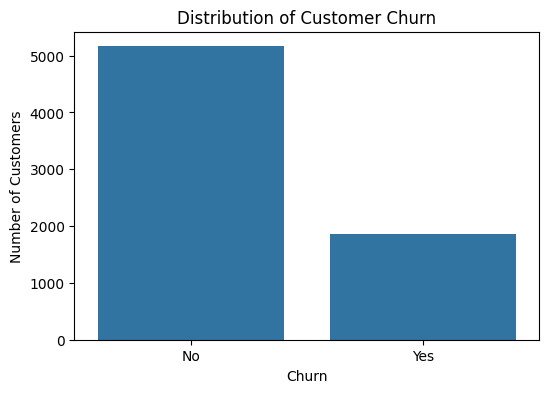

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=telco_churn_df_subset, x="Churn")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

#### target variable is imbalanced, more customers remain than churn. accuracy itself isn't sufficient to evaluate the model.

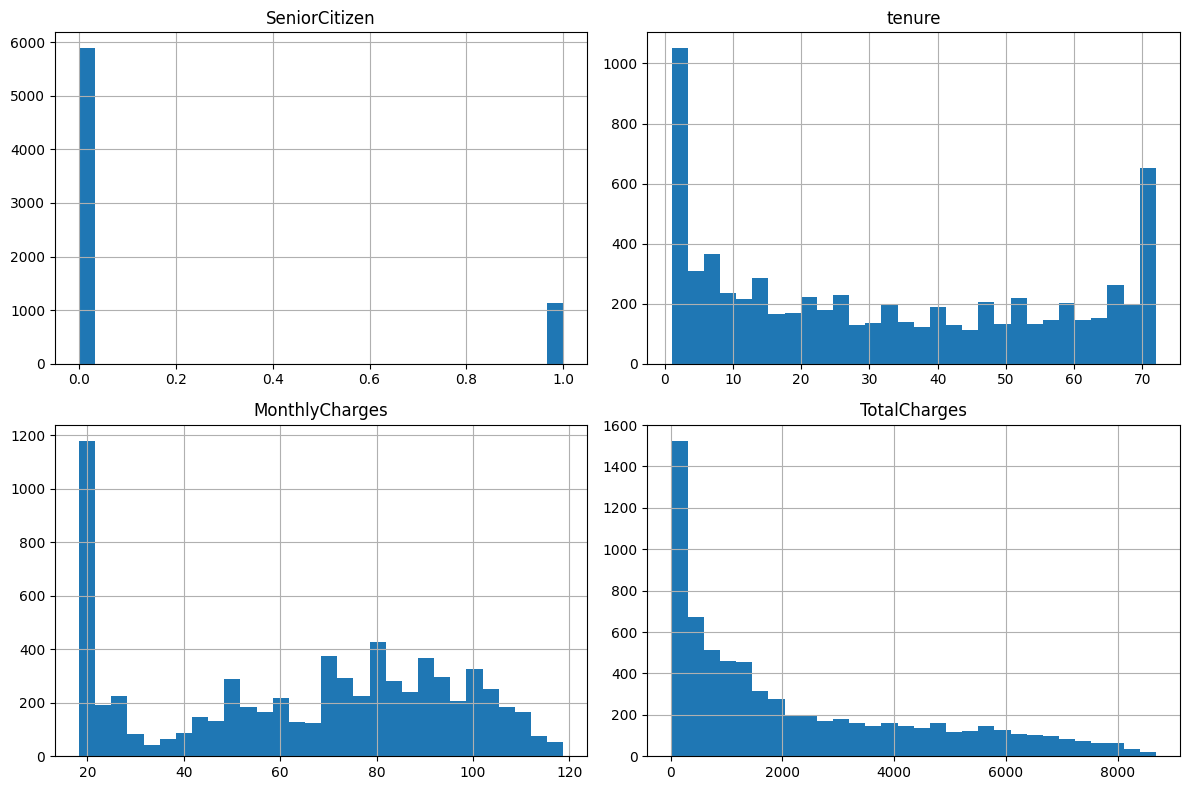

In [15]:
telco_churn_df_subset[numeric_cols].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

*senior citizen*: binary. the plot shows that the vast majority of customers are not senior citizens, while a much smaller group are.

*tenure*: the distribution has a large concentration of customers with very short tenure, particularly around the first few months. there are also many customers with long tenure, around 72 months. it is also not normally distributed, there is a large chunk of newer customers that may more likely churn.

*monthly charges*: monthly charges have a lot of variation. might be helpful to investigate whether customers paying higher monthly charges have higher churn rates.

*total charges*: strongly right skewed. makes sense for it to be related to tenure and how much each customer pays each month. 

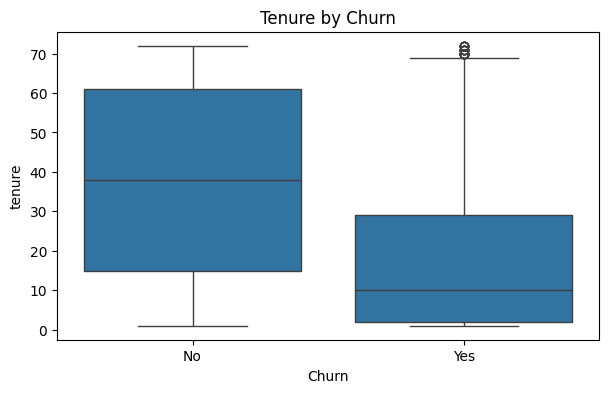

In [16]:
# numeric predictors vs churn

# tenure
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=telco_churn_df_subset,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn")
plt.show()

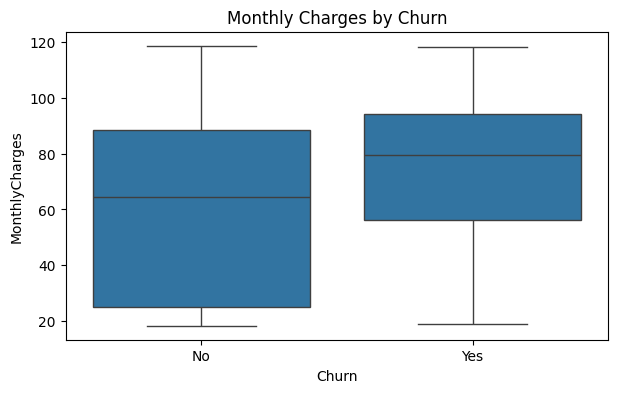

In [17]:
# monthly charges
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=telco_churn_df_subset,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.show()

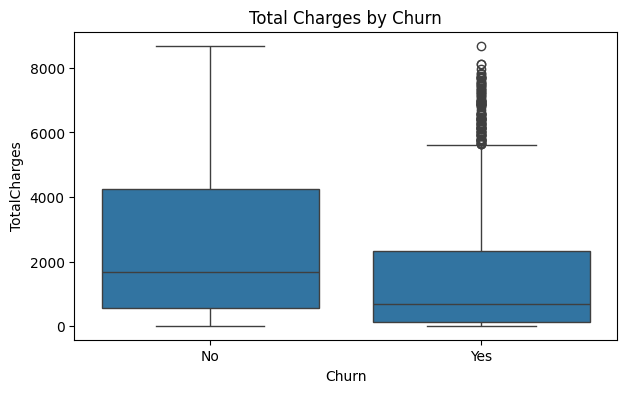

In [18]:
# total charges vs churn
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=telco_churn_df_subset,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn")
plt.show()

TotalCharges appears strongly associated with churn, but its relationship with tenure could show that we should be careful about interpreting it as an independent effect. 

Customers paying higher monthly charges appear more likely to churn. The relationship may not be perfectly linear, which makes MonthlyCharges a reasonable candidate for a GAM smooth term.

Customers with shorter tenure appear more likely to churn. This shows us that the relationship between tenure and churn is important and potentially nonlinear, making tenure a strong candidate for a GAM smooth.

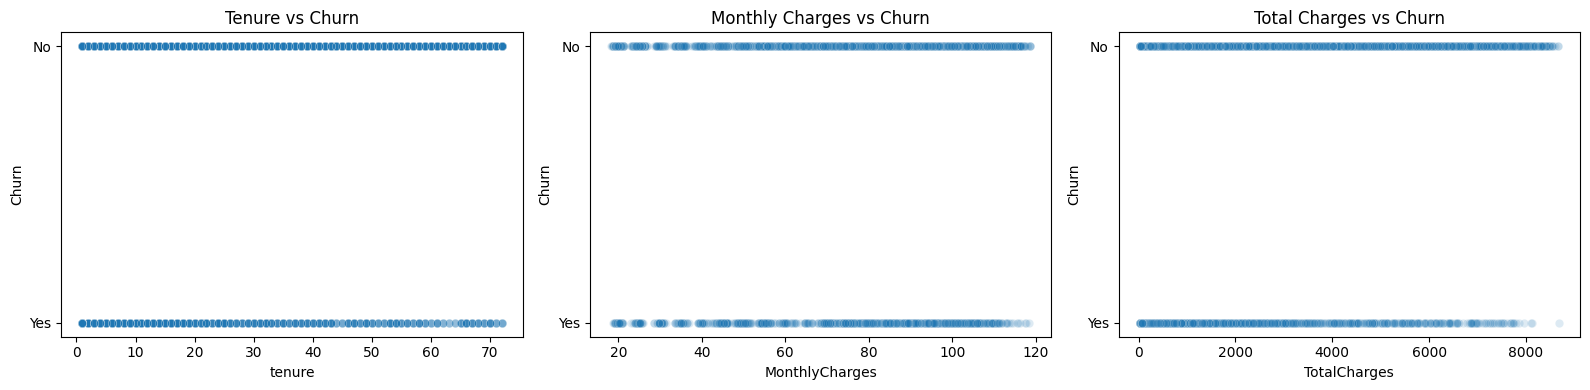

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(
    data=telco_churn_df_subset,
    x="tenure",
    y="Churn",
    alpha=0.15,
    ax=axes[0]
)

axes[0].set_title("Tenure vs Churn")

sns.scatterplot(
    data=telco_churn_df_subset,
    x="MonthlyCharges",
    y="Churn",
    alpha=0.15,
    ax=axes[1]
)

axes[1].set_title("Monthly Charges vs Churn")

sns.scatterplot(
    data=telco_churn_df_subset,
    x="TotalCharges",
    y="Churn",
    alpha=0.15,
    ax=axes[2]
)

axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()

In [20]:
telco_churn_df_subset["Churn"] = (
    telco_churn_df_subset["Churn"]
    .map({"Yes": 1, "No": 0})
)

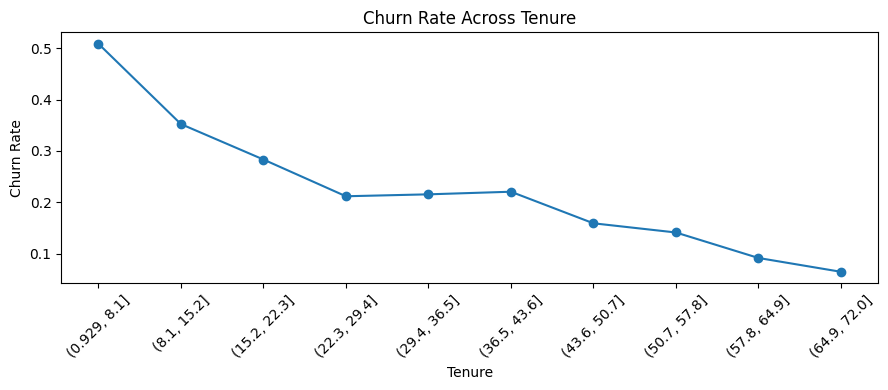

In [21]:
telco_churn_df_subset["tenure_bin"] = pd.cut(
    telco_churn_df_subset["tenure"],
    bins=10
)

tenure_churn = telco_churn_df_subset.groupby(
    "tenure_bin",
    observed=True
)["Churn"].mean()

plt.figure(figsize=(9, 4))

plt.plot(
    range(len(tenure_churn)),
    tenure_churn,
    marker="o"
)

plt.xticks(
    range(len(tenure_churn)),
    tenure_churn.index.astype(str),
    rotation=45
)

plt.ylabel("Churn Rate")
plt.xlabel("Tenure")
plt.title("Churn Rate Across Tenure")
plt.tight_layout()
plt.show()

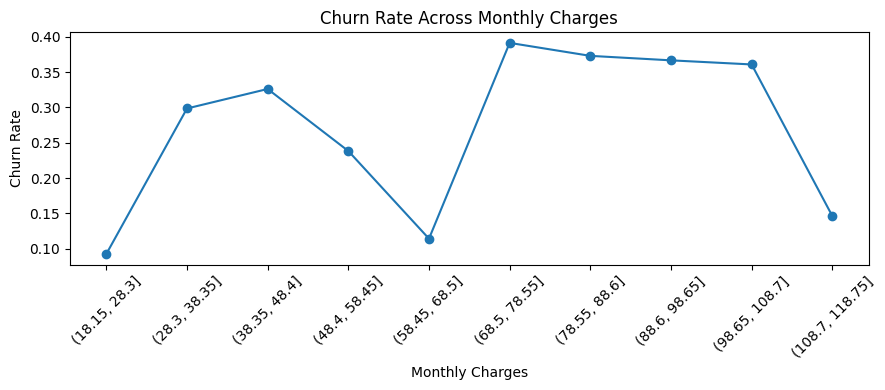

In [22]:
telco_churn_df_subset["monthlycharges_bin"] = pd.cut(
    telco_churn_df_subset["MonthlyCharges"],
    bins=10
)

monthlycharges_churn = telco_churn_df_subset.groupby(
    "monthlycharges_bin",
    observed=True
)["Churn"].mean()

plt.figure(figsize=(9, 4))

plt.plot(
    range(len(monthlycharges_churn)),
    monthlycharges_churn,
    marker="o"
)

plt.xticks(
    range(len(monthlycharges_churn)),
    monthlycharges_churn.index.astype(str),
    rotation=45
)

plt.ylabel("Churn Rate")
plt.xlabel("Monthly Charges")
plt.title("Churn Rate Across Monthly Charges")
plt.tight_layout()
plt.show()

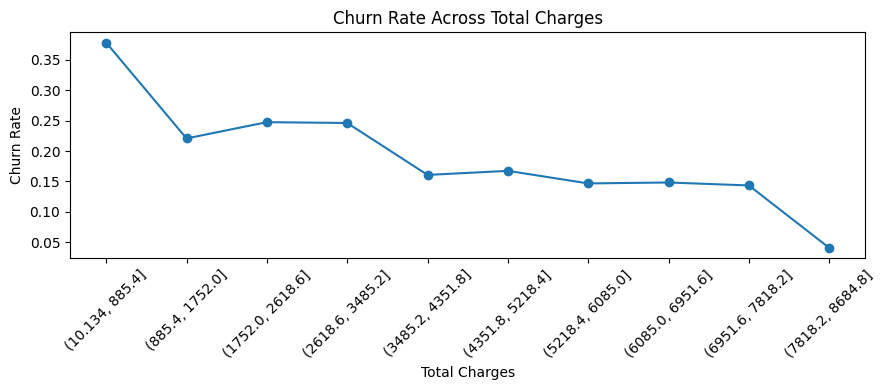

In [23]:
telco_churn_df_subset["totalcharges_bin"] = pd.cut(
    telco_churn_df_subset["TotalCharges"],
    bins=10
)

totalcharges_churn = telco_churn_df_subset.groupby(
    "totalcharges_bin",
    observed=True
)["Churn"].mean()

plt.figure(figsize=(9, 4))

plt.plot(
    range(len(totalcharges_churn)),
    totalcharges_churn,
    marker="o"
)

plt.xticks(
    range(len(totalcharges_churn)),
    totalcharges_churn.index.astype(str),
    rotation=45
)

plt.ylabel("Churn Rate")
plt.xlabel("Total Charges")
plt.title("Churn Rate Across Total Charges")
plt.tight_layout()
plt.show()

churn behavior can differ a lot between newer and longer-tenured customers. also based on what their total and monthly charges look like. this shows that allowing the model to learn a nonlinear smooth function might be more useful than imposing a single linear coefficient

In [24]:
# categorical variables

categorical_cols = telco_churn_df_subset.select_dtypes(
    include="object"
).columns

categorical_cols

/var/folders/1j/7mvpw6xj03dfzfm5gsk1d3dw0000gn/T/ipykernel_21874/1140337588.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = telco_churn_df_subset.select_dtypes(


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [25]:
for col in categorical_cols:
    churn_rate = (
        telco_churn_df_subset.groupby(col)["Churn"]
        .mean()
        .sort_values(ascending=False)
    )
    
    print(f"\n{col}")
    print(churn_rate)


gender
gender
Female    0.269595
Male      0.262046
Name: Churn, dtype: float64

Partner
Partner
No     0.329761
Yes    0.197171
Name: Churn, dtype: float64

Dependents
Dependents
No     0.312791
Yes    0.155312
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    0.267475
No     0.250000
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes    0.286485
No     0.250812
0      0.250000
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No     0.417787
Yes    0.146402
0      0.074342
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No     0.399417
Yes    0.215670
0      0.074342
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No     0.391403
Yes    0.225393
0      0.074342
Name: Churn, dtype: float64

TechSupport
TechSupport
No     0.416475
Yes    0.151961
0      0.074342
Name: Churn, dtype: float64

StreamingTV

contract, payment method, internet service, support/security - could have strong relationships with churn


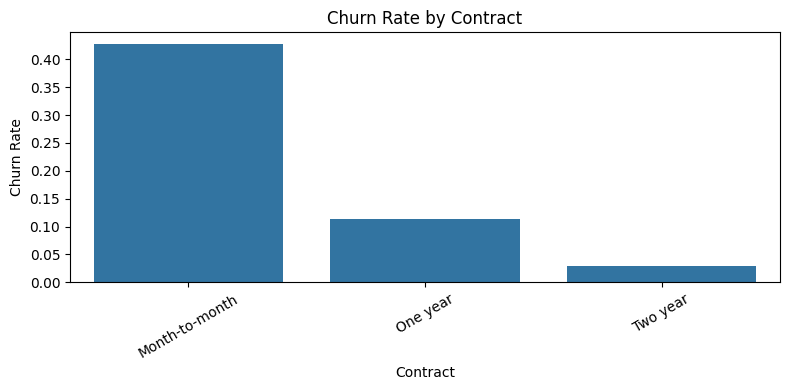

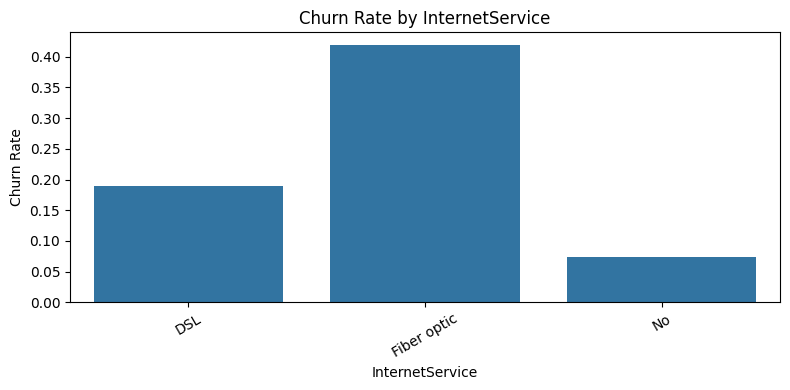

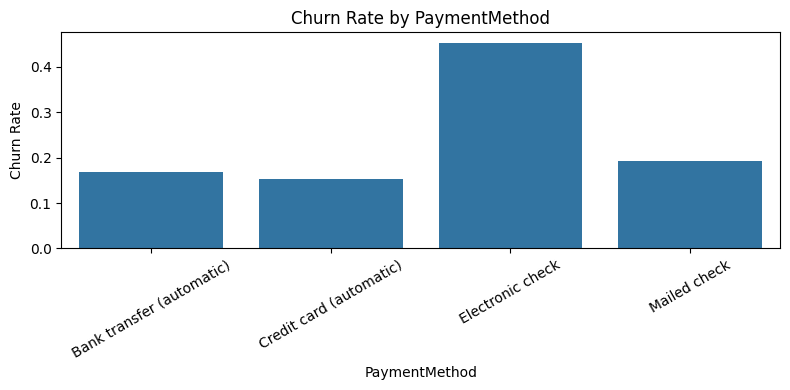

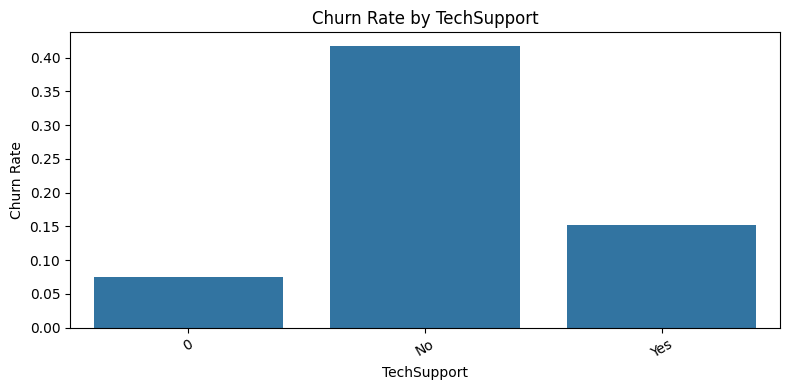

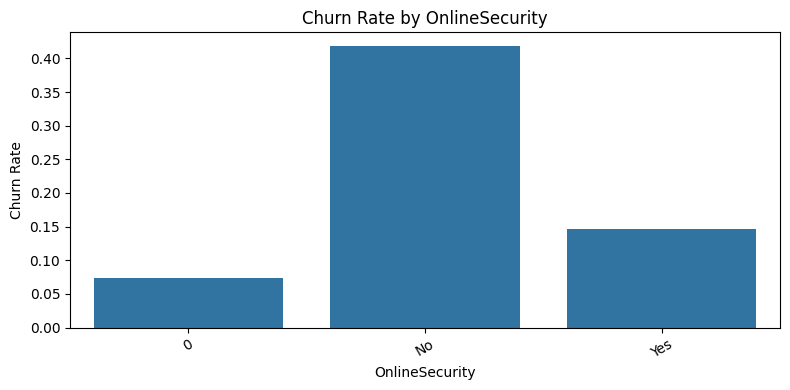

In [26]:
cols_to_plot = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]

for col in cols_to_plot:
    
    plt.figure(figsize=(8, 4))
    
    churn_rate = telco_churn_df_subset.groupby(col)["Churn"].mean()
    
    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values
    )
    
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

these results suggest that several categorical predictors may be important in explaining churn. unlike continuous predictors such as tenure and monthly charges, these variables do not require smooth functions in a GAM and can instead be represented using categorical/linear terms.

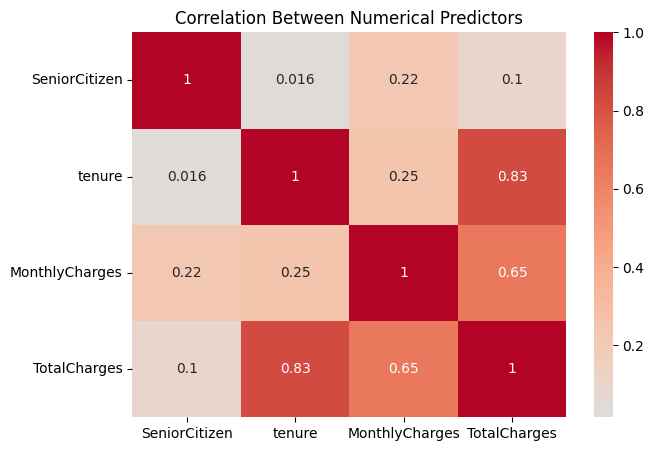

In [27]:
# correlation between numeric vars
plt.figure(figsize=(7, 5))

sns.heatmap(
    telco_churn_df_subset[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Predictors")
plt.show()

In [28]:
# model set up

model_df = telco_churn_df_subset.drop(
    columns=["customerID", "tenure_bin"],
    errors="ignore"
).copy()

In [29]:
X = pd.get_dummies(
    model_df.drop(columns=["Churn"]),
    drop_first=True,
    dtype=float
)

y = model_df["Churn"]


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
# telling gam which columns should be smooth
feature_names = X_train.columns.tolist()

for i, feature in enumerate(feature_names):
    print(i, feature)

0 SeniorCitizen
1 tenure
2 MonthlyCharges
3 TotalCharges
4 gender_Male
5 Partner_Yes
6 Dependents_Yes
7 PhoneService_Yes
8 MultipleLines_No
9 MultipleLines_Yes
10 InternetService_Fiber optic
11 InternetService_No
12 OnlineSecurity_No
13 OnlineSecurity_Yes
14 OnlineBackup_No
15 OnlineBackup_Yes
16 DeviceProtection_No
17 DeviceProtection_Yes
18 TechSupport_No
19 TechSupport_Yes
20 StreamingTV_No
21 StreamingTV_Yes
22 StreamingMovies_No
23 StreamingMovies_Yes
24 Contract_One year
25 Contract_Two year
26 PaperlessBilling_Yes
27 PaymentMethod_Credit card (automatic)
28 PaymentMethod_Electronic check
29 PaymentMethod_Mailed check
30 monthlycharges_bin_(28.3, 38.35]
31 monthlycharges_bin_(38.35, 48.4]
32 monthlycharges_bin_(48.4, 58.45]
33 monthlycharges_bin_(58.45, 68.5]
34 monthlycharges_bin_(68.5, 78.55]
35 monthlycharges_bin_(78.55, 88.6]
36 monthlycharges_bin_(88.6, 98.65]
37 monthlycharges_bin_(98.65, 108.7]
38 monthlycharges_bin_(108.7, 118.75]
39 totalcharges_bin_(885.4, 1752.0]
40 to

In [32]:
from pygam import LogisticGAM, s, l

terms = (
    s(1) +              # tenure
    s(2) +              # MonthlyCharges
    s(3)                # TotalCharges
)

for i in range(len(feature_names)):
    if i not in [1, 2, 3]:
        terms += l(i)

In [33]:
gam = LogisticGAM(terms)

gam.gridsearch(
    X_train.values,
    y_train.values
)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:05
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:03
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:01
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:01 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:01 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01


LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(1) + s(2) + s(3) + l(0) + l(4) + l(5) + l(6) + l(7) + l(8) + l(9) + l(10) + l(11) + l(12) + l(13) + l(14) + l(15) + l(16) + l(17) + l(18) + l(19) + l(20) + l(21) + l(22) + l(23) + l(24) + l(25) + l(26) + l(27) + l(28) + l(29) + l(30) + l(31) + l(32) + l(33) + l(34) + l(35) + l(36) + l(37) + l(38) + l(39) + l(40) + l(41) + l(42) + l(43) + l(44) + l(45) + l(46) + l(47) + intercept,
   tol=0.0001, verbose=False)

### Performance Evaluation

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = gam.predict(X_test.values)
y_prob = gam.predict_proba(X_test.values)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.798862828713575
Precision: 0.6463022508038585
Recall   : 0.5374331550802139
F1 Score : 0.5868613138686132
ROC-AUC  : 0.8416623095599236


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



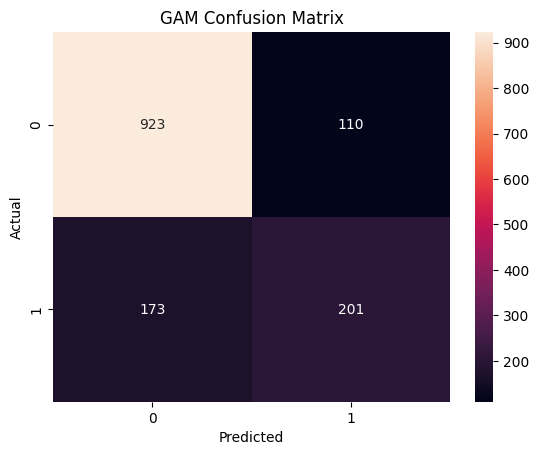

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GAM Confusion Matrix")
plt.show()

The GAM correctly classified 923 customers who did not churn and 201 customers who did churn. It incorrectly classified 110 non-churners as churners and missed 173 customers who actually churned. The model therefore identifies approximately 53.7% of actual churners, indicating that while the overall classification accuracy is relatively high, there is still substantial room for improvement in identifying customers at risk of churn.

This is particularly important for churn prediction because false negatives represent customers who are predicted to stay but ultimately leave. Therefore, accuracy alone does not provide a complete picture of model performance, and recall, F1-score, and ROC-AUC should also be considered.

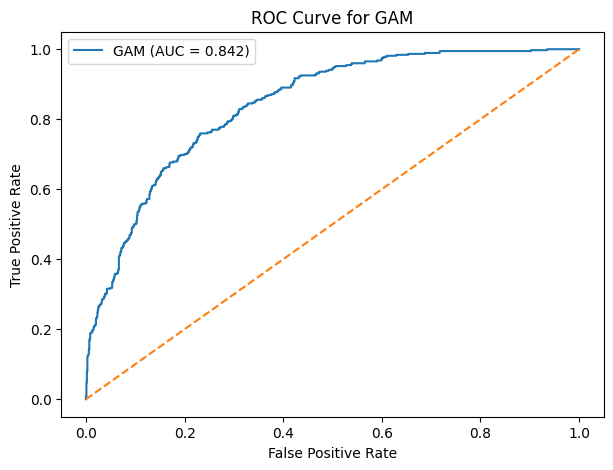

In [37]:
# roc curve

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"GAM (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for GAM")
plt.legend()
plt.show()

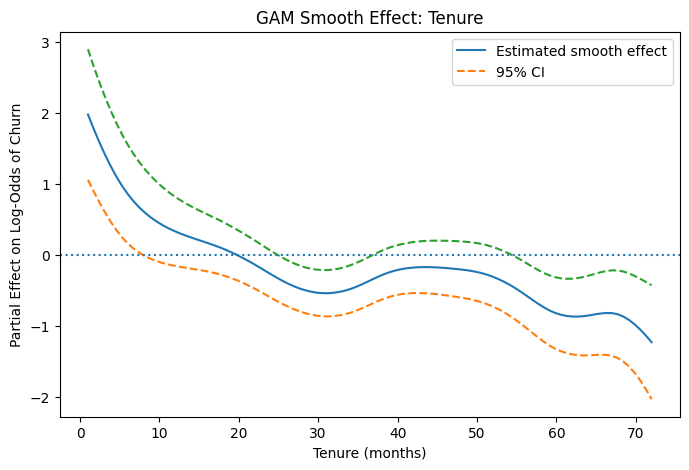

In [38]:
# smooth effect - tenure

# Generate values across the range of tenure
XX = gam.generate_X_grid(term=0)

# Get partial dependence and confidence interval
pdep, confi = gam.partial_dependence(
    term=0,
    X=XX,
    width=0.95
)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    XX[:, 1],
    pdep,
    label="Estimated smooth effect"
)

plt.plot(
    XX[:, 1],
    confi[:, 0],
    linestyle="--",
    label="95% CI"
)

plt.plot(
    XX[:, 1],
    confi[:, 1],
    linestyle="--"
)

plt.axhline(
    0,
    linestyle=":"
)

plt.xlabel("Tenure (months)")
plt.ylabel("Partial Effect on Log-Odds of Churn")
plt.title("GAM Smooth Effect: Tenure")
plt.legend()
plt.show()

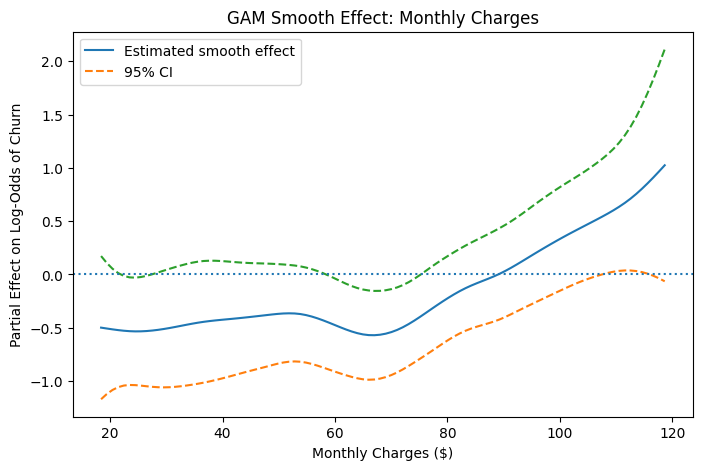

In [39]:
XX = gam.generate_X_grid(term=1)

pdep, confi = gam.partial_dependence(
    term=1,
    X=XX,
    width=0.95
)

plt.figure(figsize=(8, 5))

plt.plot(
    XX[:, 2],
    pdep,
    label="Estimated smooth effect"
)

plt.plot(
    XX[:, 2],
    confi[:, 0],
    linestyle="--",
    label="95% CI"
)

plt.plot(
    XX[:, 2],
    confi[:, 1],
    linestyle="--"
)

plt.axhline(
    0,
    linestyle=":"
)

plt.xlabel("Monthly Charges ($)")
plt.ylabel("Partial Effect on Log-Odds of Churn")
plt.title("GAM Smooth Effect: Monthly Charges")
plt.legend()
plt.show()

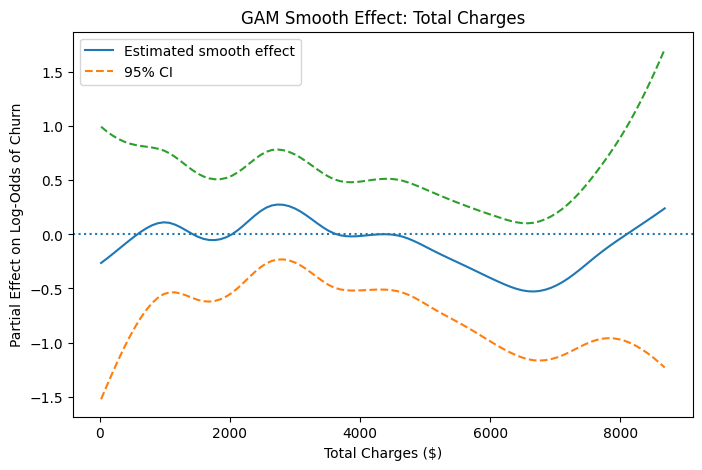

In [40]:
XX = gam.generate_X_grid(term=2)

pdep, confi = gam.partial_dependence(
    term=2,
    X=XX,
    width=0.95
)

plt.figure(figsize=(8, 5))

plt.plot(
    XX[:, 3],
    pdep,
    label="Estimated smooth effect"
)

plt.plot(
    XX[:, 3],
    confi[:, 0],
    linestyle="--",
    label="95% CI"
)

plt.plot(
    XX[:, 3],
    confi[:, 1],
    linestyle="--"
)

plt.axhline(
    0,
    linestyle=":"
)

plt.xlabel("Total Charges ($)")
plt.ylabel("Partial Effect on Log-Odds of Churn")
plt.title("GAM Smooth Effect: Total Charges")
plt.legend()
plt.show()

### smooth effect summary
Tenure: Churn risk is highest for customers with very low tenure and generally decreases as tenure increases. The relationship is clearly nonlinear.

Monthly Charges: The effect is fairly low/negative at lower charges but increases noticeably at higher monthly charges, suggesting that higher-paying customers have greater churn risk.

Total Charges: The effect fluctuates across the range rather than following a consistent linear pattern. It is mostly around zero to slightly negative for many values, with some increase at very high total charges.

## FINAL SUMMARY

All predictors except customerID were included in the model. Continuous variables were modeled using smooth terms, while categorical variables were represented using linear terms after encoding.
Overall, the GAM achieved a ROC-AUC of 0.842 and captured nonlinear relationships between continuous customer characteristics and churn. The smooth effects suggest that tenure and monthly charges have changing effects across their ranges, demonstrating the interpretability advantage of GAMs.

Limitations of GAM:

It assumes the effects of predictors are additive unless their interactions are explicitly included. In reality, churn may depend on combinations of variables, such as contract type and monthly charges.

Another limitation is that tenure and TotalCharges are correlated, which can make their individual smooth effects harder to interpret. The GAM provides useful and interpretable relationships, it may not entirely capture complex interactions.